In [1]:
import os
import fixing
from ParseEvent import ParseEvent
import pickle
import pandas as pd
dir = r'D:\zyy_records\A04' 
log_dir=r'D:\zyy_progs\llcom\logs'
def find_evt_files_without_pkl(dir=str):
    evt_files_without_pkl = []
    for root, dirs, files in os.walk(dir):
        for file in files:
            if file.endswith('.evt'):
                pkl_file_name = os.path.splitext(file)[0] + '.pkl'
                if pkl_file_name not in files:
                    evt_file_path = os.path.join(root, file)
                    evt_files_without_pkl.append(evt_file_path)
    
    return evt_files_without_pkl

Paths = find_evt_files_without_pkl(dir)
count=4
Event=None
if(len(Paths)==0):
    print('No evt to be processed!\n')
else:
    print('Find '+str(len(Paths))+' File(s)!')
delta1=26000
delta2=39000
df = pd.DataFrame()
if os.path.exists(os.path.join(dir,"README.xlsx")):
    df = pd.read_excel(os.path.join(dir,"README.xlsx"),sheet_name='Sheet1',header=None) .iloc[2:,:]
    print('Find CSV data!')


Find 10 File(s)!
Find CSV data!


In [2]:
# You can edit data here
if (count < len(Paths)):
    print('Processing file '+str(count+1)+'/'+str(len(Paths))+': '+Paths[count])
    Event=ParseEvent(Paths[count])
    target_date = os.path.basename(Paths[count]).split('_')[0]
    log_file = os.path.join(log_dir, f"log{target_date}.txt")

    matched_row=pd.DataFrame
    if not df.empty:
        matched_row = df[df[0]==int(target_date)] 
    fixing.fixing(Event,26000,39000,log_file,matched_row)
else:
    print('All Finished!\n')

Processing file 5/10: D:\zyy_records\A04\20250318_00.evt
Removed an abnormal event
Log file D:\zyy_progs\llcom\logs\log20250318.txt found. Event is matched to 3, time difference is 0 seconds.
Fixing with log! 
218/218 matched! a=0.9999913385475238, b=2913.130076497793 
107/107 matched! a=0.9997455847174377, b=8693.326563127339 
183/184 matched! a=1.000017412979462, b=-797.9690874367952 
3Events matched! a=0.9999181120814744±0.00012245880261358298, b=0.07205658368125557±0.07810751039575536 (seconds)
No SlnR Event! Fixing 

No ModR Event! Fixing 

8 8


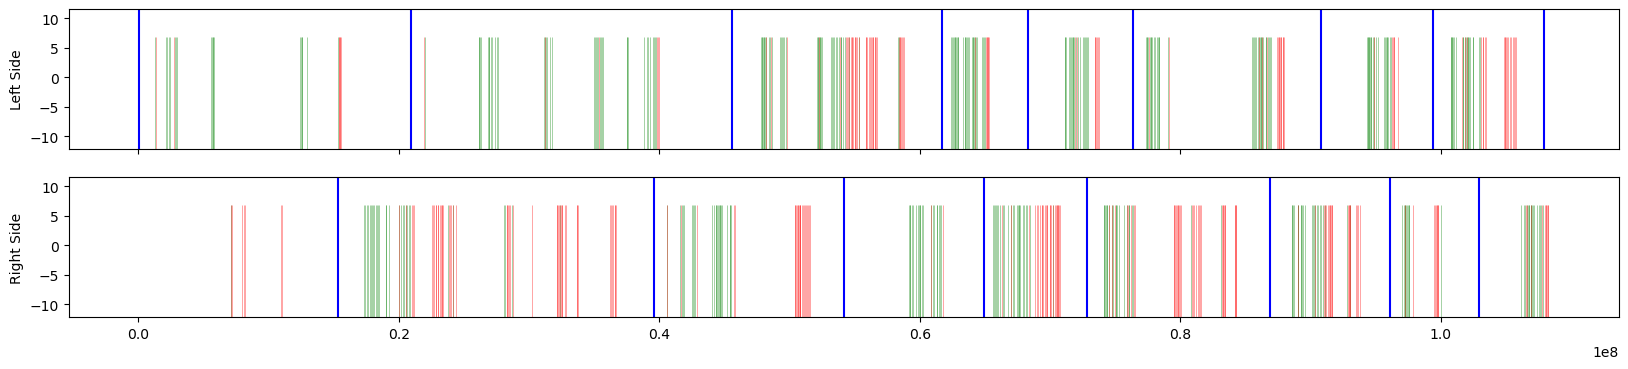

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 4), 
                                   gridspec_kw={'height_ratios': [1, 1]},sharex=True,)
sns.rugplot(Event['SlnL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['SlnR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='green',alpha=0.5)
sns.rugplot(Event['ROmL']['Time_S'] , ax=ax1, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ROmR']['Time_S'] , ax=ax2, height=0.8, linewidth=0.5, color='red',alpha=0.5)
sns.rugplot(Event['ModL']['Time_S'] , ax=ax1, height=1, linewidth=1.5, color='blue')
sns.rugplot(Event['ModR']['Time_S'] , ax=ax2, height=1, linewidth=1.5, color='blue')
ax1.set_ylabel('Left Side')
ax2.set_ylabel('Right Side')
plt.show()

In [ ]:
if (Event != None):
    pkl_path=os.path.splitext(Paths[count])[0] + '.pkl'
    with open(pkl_path,"wb") as pkl_f:
        pickle.dump(Event,pkl_f)
        Event=None
    print('File Saved!\n')
else:
    print('Event = Null!! Pkl won\'t be saved!')
count += 1

File Saved!



Process All File Automatically！

In [ ]:
while (count < len(Paths)):
    Event=ParseEvent(Paths[count])
    fixing.fixing(Event,delta1,delta2)
    print('Processing file '+str(count+1)+'/'+str(len(Paths))+': '+Paths[count])
    if (Event != None):
        pkl_path=os.path.splitext(Paths[count])[0] + '.pkl'
        with open(pkl_path,"wb") as pkl_f:
            pickle.dump(Event,pkl_f)
            Event=None
        print('File Saved!\n')
    else:
        print('Event = Null!! Pkl won\'t be saved!')
    count += 1
else:
    print('All Finished!\n')
    

All Finished!



27000 39000


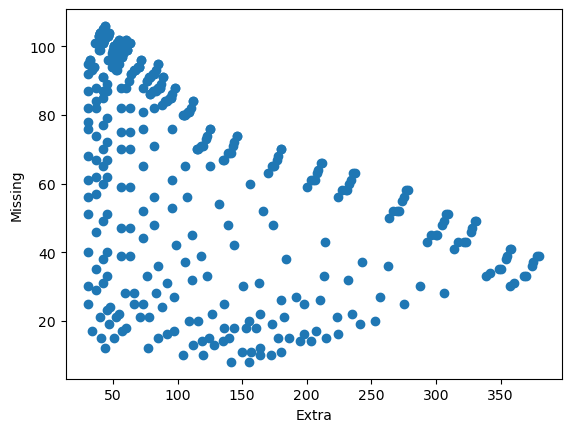

In [ ]:
#如果需要修正,可以从这里估算参数 i j 分别对应delta1和delta2  反正 就是 取那一组没问题的数据 相互验证
import matplotlib.pyplot as plt
seq={
    'i':[],
    'j':[],
    'delta2':[],
    'delta_2':[] 
}
seq_=[]
for i in range (20,40):
    for j in range (20,40):
        recog  = fixing.recog_trials(Event['LickL']['Time_S'],delta=i*1000)

        delta1 = fixing.find_not_matched(recog,Event['ROmL']['Time_S'],delta=j*1000)
        delta2 = fixing.find_not_matched(delta1,Event['SlnL']['Time_S'],delta=j*1000)  #多的

        delta_1 = fixing.find_not_matched(Event['ROmL']['Time_S'],recog,delta=j*1000)
        delta_2 = fixing.find_not_matched(delta_1,Event['SlnL']['Time_S'],delta=j*1000)   #少的
        seq['i'].append(i)
        seq['j'].append(j)
        seq['delta2'].append(len(delta2))
        seq['delta_2'].append(len(delta_2))
        seq_.append([i,j,len(delta2)+len(delta_2)])  #按照总误差排序
plt.scatter(seq['delta2'],seq['delta_2'])
plt.xlabel('Extra')
plt.ylabel('Missing')
seq_.sort(key=lambda x:abs(x[0]-x[1]))
seq_.sort(key=lambda x:x[2])  
print(seq_[0][0]*1000,seq_[0][1]*1000)